<a href="https://colab.research.google.com/github/o0meerkat0o/aIND_realdata/blob/main/aIND_real_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# aIND on real DNS channel flow data (Re_tau = 180)

This notebook runs the informative / non-informative decomposition from Arranz & Lozano-Duran (JFM 2024) on real turbulence data, the UPC channel flow dataset at Re_tau = 180.

Setup we're reproducing: the source is the streamwise velocity fluctuation at a plane some distance off the wall, and the target is the wall shear stress a bit later in time. The method splits the velocity into the part that actually carries information about the future wall stress (Phi_I) and the part that doesn't (Phi_R).

Everything in here uses details we already verified by hand on this dataset:
- field keys inside each snapshot are u_data, v_data, w_data, p_data
- arrays are shaped (130, 130, 258) with axis order (z, y, x), confirmed by checking which axis each mesh coordinate varies along
- the extra 2 points per axis are ghost cells, the real grid is the interior 128 x 128 x 256
- rho = 1 and nu = 1/180 exactly, from the dataset README, so the mean wall shear stress should come out near 1.0, which we use as a built in check

Data expected in Drive at MyDrive/comsail/, with the Mesh folder and the 0-150_LETOTs folder of snapshot files.

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/Computational-Turbulence-Group/aIND.git

Cloning into 'aIND'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 1), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 14.88 KiB | 1.06 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
# the repo was written for an older pytorch where ReduceLROnPlateau had a
# verbose argument. newer versions removed it and training crashes without this
!sed -i "s/verbose=True,//" aIND/IND/bijectiveNN.py aIND/IND/surjectiveNN.py

In [ ]:
import sys, glob
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "aIND")
from IND.bijectiveNN import bijectiveNN
from IND.surjectiveNN import surjectiveNN
from IND import mikde

np.random.seed(0)
torch.manual_seed(0)

## Settings

Everything tunable lives here so reruns with different choices don't mean hunting through the notebook.

In [ ]:
DATA_DIR  = "/content/drive/MyDrive/comsail/0-150_LETOTs"
MESH_PATH = "/content/drive/MyDrive/comsail/Mesh/3d_turbulent_channel_flow-MESH.h5"

rho = 1.0
nu  = 1.0 / 180.0     # from Re_tau = u_tau * delta / nu with u_tau = delta = 1

# which y plane the source velocity comes from. index 15 in the trimmed grid
# is a modest distance off the wall, past the viscous sublayer but still in
# the near wall region where the paper says most of the informative content is
y_idx_source = 15

# time lag between source and target, in snapshot steps. the paper uses a lag
# of about 25 wall units. our snapshots are farther apart than that, so this
# is the closest we can do with the current files, revisit if we pull more
dtlag = 1

## Load the mesh and get the wall normal coordinate

The mesh stores full 3D coordinate arrays even though the grid is Cartesian, so each coordinate only actually varies along one axis. We checked this by hand: x varies along array axis 2 (range about 12.6, matching 4 pi), y along axis 1 (range 2.0, the channel height), z along axis 0 (range 4.2, matching 4 pi / 3). So the axis order is (z, y, x).

In [ ]:
with h5py.File(MESH_PATH, "r") as f:
    y_full = f["y"][:]

# pull one clean line of y values, trimmed of the ghost point on each end.
# y varies along axis 1, the other two indices can be anything
y_line = y_full[0, 1:-1, 0]

print("first few y values:", y_line[:5])
print("y range:", y_line.min(), "to", y_line.max())
print("first off-wall point at y+ =", y_line[0] * 180)   # should be ~0.1 per the README

first few y values: [0.00057389 0.00223128 0.00455923 0.00754701 0.01118387]
y range: 0.0005738884210586548 to 1.9994261115789413
first off-wall point at y+ = 0.10329991579055786


## Load the snapshots and compute wall shear stress

For each snapshot: trim the ghost cells, keep the streamwise velocity, and compute the wall shear stress ourselves since it isn't stored in the files. The no slip condition means u is exactly zero at the wall, so the velocity gradient there is just u at the first interior point divided by its distance to the wall.

The printed mean should land close to 1.0. That's not a coincidence, the simulation is normalized so tau_w = rho * u_tau^2 = 1, so this doubles as a check that our axis order and trimming are right.

In [ ]:
snapshot_files = sorted(glob.glob(DATA_DIR + "/*.h5"))
print(f"found {len(snapshot_files)} snapshots")

u_list, tau_list = [], []

for path in snapshot_files:
    with h5py.File(path, "r") as f:
        u_raw = f["u_data"][:]
    u_snap = u_raw[1:-1, 1:-1, 1:-1]          # trim ghosts, shape (128, 128, 256) = (z, y, x)
    u_list.append(u_snap)

    dudy_wall = u_snap[:, 0, :] / y_line[0]    # gradient at the y=0 wall
    tau_list.append(rho * nu * dudy_wall)      # shape (z, x)

u_stack   = np.stack(u_list)                   # (time, z, y, x)
tau_stack = np.stack(tau_list)                 # (time, z, x)

print("u_stack:", u_stack.shape, "  tau_stack:", tau_stack.shape)
print("mean wall shear stress:", tau_stack.mean(), " (should be close to 1.0)")

found 15 snapshots
u_stack: (15, 128, 128, 256)   tau_stack: (15, 128, 256)
mean wall shear stress: 0.99309052544152  (should be close to 1.0)


## Quick sanity plots

Three checks before training anything: the mean velocity profile should be a channel shape, the near wall velocity should show the classic streak pattern, and the wall stress field should look like a smoother version of those streaks. If any of these look wrong, stop and fix the loading before going further.

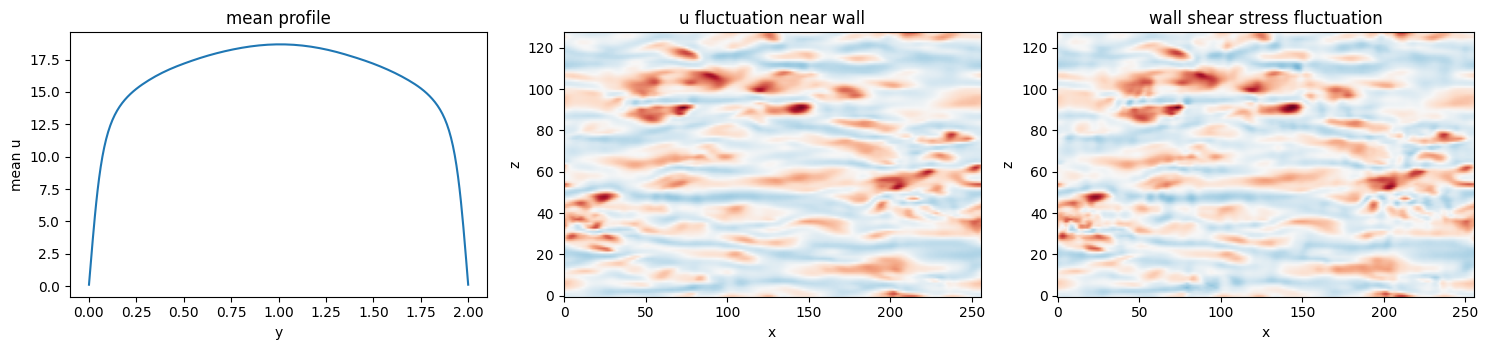

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.6))

# mean profile over all snapshots and both homogeneous directions
U_mean = u_stack.mean(axis=(0, 1, 3))
axs[0].plot(y_line, U_mean)
axs[0].set_xlabel("y"); axs[0].set_ylabel("mean u")
axs[0].set_title("mean profile")

# near wall streaks, one snapshot
sl = u_stack[0, :, 5, :]
fl = sl - sl.mean()
v = np.abs(fl).max()
axs[1].imshow(fl, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto", origin="lower")
axs[1].set_title("u fluctuation near wall")
axs[1].set_xlabel("x"); axs[1].set_ylabel("z")

# wall shear stress, same snapshot
tf = tau_stack[0] - tau_stack[0].mean()
v = np.abs(tf).max()
axs[2].imshow(tf, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto", origin="lower")
axs[2].set_title("wall shear stress fluctuation")
axs[2].set_xlabel("x"); axs[2].set_ylabel("z")

plt.tight_layout()
plt.show()

## Build the source and target for aIND

Source Phi: streamwise velocity fluctuation at the chosen y plane. Target Psi: wall shear stress fluctuation. Both get their means subtracted, since the method works on fluctuations, same as the paper.

We do not shift the arrays in time here. Training handles the lag itself through the dtlag argument, the dataset code inside the repo rolls the target array and trims the wrapped edge. The manual shift comes later, at decomposition time, because the inference function expects pre shifted arrays (its docstring says so explicitly).

In [ ]:
Phi = u_stack[:, :, y_idx_source, :]      # (time, z, x)
Psi = tau_stack                            # (time, z, x)

Phi = Phi - Phi.mean()
Psi = Psi - Psi.mean()

print("Phi:", Phi.shape, "  Psi:", Psi.shape)
print("Phi std:", Phi.std().round(4), "  Psi std:", Psi.std().round(4))

Phi: (15, 128, 256)   Psi: (15, 128, 256)
Phi std: 2.5713   Psi std: 0.3506


## Is the mapping one to one?

This decides which model to use. If the scatter of (Phi, Psi) looks like a single noisy trend, the simple bijectiveNN is enough. If it clearly folds back on itself like a parabola, we'd need the surjectiveNN with multiple branches. For velocity vs wall stress this is expected to be a rising trend, faster fluid near the wall drags harder on it, so bijective is the default here.

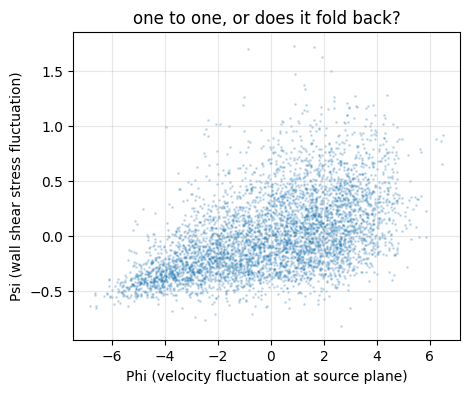

In [ ]:
sub = np.random.choice(Phi.size, 5000, replace=False)
plt.figure(figsize=(5,4))
plt.scatter(Phi.ravel()[sub], Psi.ravel()[sub], s=1, alpha=.2)
plt.xlabel("Phi (velocity fluctuation at source plane)")
plt.ylabel("Psi (wall shear stress fluctuation)")
plt.title("one to one, or does it fold back?")
plt.grid(alpha=.3)
plt.show()

## Set up and train the model

bijectiveNN with a DSF, the invertible monotone network from the paper's appendix, 3 layers of 12 neurons matching what they used. Training in two stages, same trick as our synthetic run: first let the MSE term dominate so the network learns the rough shape of the mapping, then bring the mutual information term up to full strength to enforce independence between the two pieces.

The Nsamples argument subsamples the millions of available grid points down to something the full batch training can handle. If you switch the Colab runtime to GPU, set run_gpu=True below for a decent speedup.

In [ ]:
obj = bijectiveNN("DSF", num_layers=3, num_neurons=12, run_gpu=False)
obj.initTrainDset(T=Psi, S=Phi, dtlag=dtlag, Nsamples=8000, Ntr=0.8)
obj.initTrainParams(lr=3e-3)

obj.initMIParams(num_bins=50, f_mi=0.05, f_mse=1.0)
obj.optimize(epochs=1200, patience=25, lr_scheduler_dic={"factor": 0.5, "patience": 5})

obj.initMIParams(num_bins=50, f_mi=0.3, f_mse=1.0)
obj.optimize(epochs=900, patience=20, lr_scheduler_dic={"factor": 0.5, "patience": 5})

Phi_s = Phi[:-dtlag]; Psi_s = Psi[dtlag:]
PhiI, PhiR = obj.get_cau_res_user(Psi_s, Phi_s)

print("std(PhiI):", PhiI.std(), "  std(PhiR):", PhiR.std())
print("E_I:", ((PhiI**2).mean() / (Phi_s**2).mean()).round(4))

Using device: cpu

      step    val loss    mse loss     mi loss
         0  1.03845978   1.03841174  0.00445456
       100  1.03439748   1.03436089  0.00339165
       200  1.03408206   1.03404665  0.00328143
       300  1.03403509   1.03400004  0.00324968
       400  1.03405070   1.03401589  0.00323124 ( >  1.03403509)  Patience: 1/25
       500  1.03416502   1.03413033  0.00322069 ( >  1.03403509)  Patience: 2/25
       600  1.03463972   1.03460479  0.00324140 ( >  1.03403509)  Patience: 3/25
       700  1.03545403   1.03541863  0.00328541 ( >  1.03403509)  Patience: 4/25
       800  1.03580558   1.03577101  0.00321266 ( >  1.03403509)  Patience: 5/25
       900  1.03596485   1.03593087  0.00315573 ( >  1.03403509)  Patience: 6/25
      1000  1.03618133   1.03614688  0.00319329 ( >  1.03403509)  Patience: 7/25
      1100  1.03646803   1.03643310  0.00323588 ( >  1.03403509)  Patience: 8/25
Optimization finished: Maximum # steps (1200) reached
Final error:  1.0368156433105469

      

In [ ]:
# stage 1: mostly mse, learn the shape of the mapping first
obj.initMIParams(num_bins=50, f_mi=0.05, f_mse=1.0)
obj.optimize(epochs=900, patience=20, lr_scheduler_dic={"factor": 0.5, "patience": 5})


      step    val loss    mse loss     mi loss


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


         0  1.27642083   1.27634728  0.00681854
       100  1.03447282   1.03441679  0.00519007
       200  1.02980673   1.02975976  0.00435560
       300  1.02833688   1.02829301  0.00406558
       400  1.02781105   1.02776849  0.00394856
       500  1.02763665   1.02759457  0.00389953
       600  1.02758992   1.02754807  0.00387960
       700  1.02758086   1.02753913  0.00387218
       800  1.02758014   1.02753842  0.00386931
Optimization finished: Maximum # steps (900) reached
Final error:  1.0275797843933105


In [ ]:
# stage 2: full mutual information term, enforce independence
obj.initMIParams(num_bins=50, f_mi=1.0, f_mse=1.0)
obj.optimize(epochs=900, patience=20, lr_scheduler_dic={"factor": 0.5, "patience": 5})


      step    val loss    mse loss     mi loss
         0  1.02837276   1.02753806  0.00386800
       100  1.02837193   1.02753735  0.00386788
       200  1.02837074   1.02753615  0.00386792
       300  1.02836978   1.02753508  0.00386836
       400  1.02836823   1.02753353  0.00386836
       500  1.02836680   1.02753210  0.00386836
       600  1.02836502   1.02753019  0.00386854
       700  1.02836418   1.02752936  0.00386863
       800  1.02836299   1.02752817  0.00386850
Optimization finished: Maximum # steps (900) reached
Final error:  1.0283621549606323


## Decompose the field

One detail that's easy to miss: get_cau_res_user expects the time shift to already be applied to the arrays you hand it, its docstring says this explicitly. So we shift here, source from the earlier times, target from dtlag steps later, then decompose.

In [ ]:
Phi_s = Phi[:-dtlag] if dtlag > 0 else Phi
Psi_s = Psi[dtlag:]  if dtlag > 0 else Psi

PhiI, PhiR = obj.get_cau_res_user(Psi_s, Phi_s)

print("PhiI:", PhiI.shape, "  PhiR:", PhiR.shape)
print("check they add back up:", np.allclose(PhiI + PhiR, Phi_s))

PhiI: (14, 128, 256)   PhiR: (14, 128, 256)
check they add back up: True


## How much of the velocity is informative?

E_I is the fraction of the source energy that ended up in the informative part, equation 2.11 in the paper. For streamwise velocity in the near wall region the paper found somewhere around half the energy is informative, so a value in that broad neighborhood is reasonable, an extreme value near 0 or 1 would be suspicious.

In [ ]:
EI = (PhiI**2).mean() / (Phi_s**2).mean()
print("relative energy of informative part E_I =", round(float(EI), 3))

relative energy of informative part E_I = 0.001


## The real test: does the residual actually know nothing?

On synthetic data we could compare against a known answer. Here there isn't one, so we use the check the paper itself uses: measure the mutual information between each piece and the target. The informative part should carry essentially all of it, the residual should carry close to none. One counterintuitive thing to expect: MI(Phi_I, Psi) often comes out larger than MI(Phi, Psi), which looks backwards at first. It isn't, the junk mixed into the raw field dilutes the pointwise estimate, and stripping it away makes the relationship easier to measure. I saw exactly this on a test run. We use the repo's own MI estimator for this, standardizing the inputs first since it assumes zero mean signals within a fixed bin range.

In [ ]:
mi_est = mikde.MutualInformation(num_bins=50, sigma="scott")

def mi_between(a, b, n=20000):
    # subsample, standardize, and shape the way the estimator expects (1 x N)
    idx = np.random.choice(a.size, min(n, a.size), replace=False)
    ta = torch.tensor((a.ravel()[idx] / a.std()), dtype=torch.float32).view(1, -1)
    tb = torch.tensor((b.ravel()[idx] / b.std()), dtype=torch.float32).view(1, -1)
    return float(mi_est.getMutualInformation(ta, tb))

print("MI(Phi,   Psi)  =", round(mi_between(Phi_s, Psi_s), 4), "  full field vs target")
print("MI(PhiI,  Psi)  =", round(mi_between(PhiI, Psi_s), 4), "  informative vs target, should be at least as large as the line above")
print("MI(PhiR,  Psi)  =", round(mi_between(PhiR, Psi_s), 4), "  residual vs target, should be much smaller")
print("MI(PhiI, PhiR)  =", round(mi_between(PhiI, PhiR), 4), "  the two pieces, should also be small")

MI(Phi,   Psi)  = 0.0016   full field vs target
MI(PhiI,  Psi)  = 0.4986   informative vs target, should be at least as large as the line above
MI(PhiR,  Psi)  = 0.0015   residual vs target, should be much smaller
MI(PhiI, PhiR)  = 0.0012   the two pieces, should also be small


## Look at the decomposition

Same style as figure 3 in the paper: the original velocity plane, its informative part, and its residual, plus the learned mapping between Phi_I and the target. The informative field should keep the streaky structure that lines up with the wall stress, the residual should look like everything else.

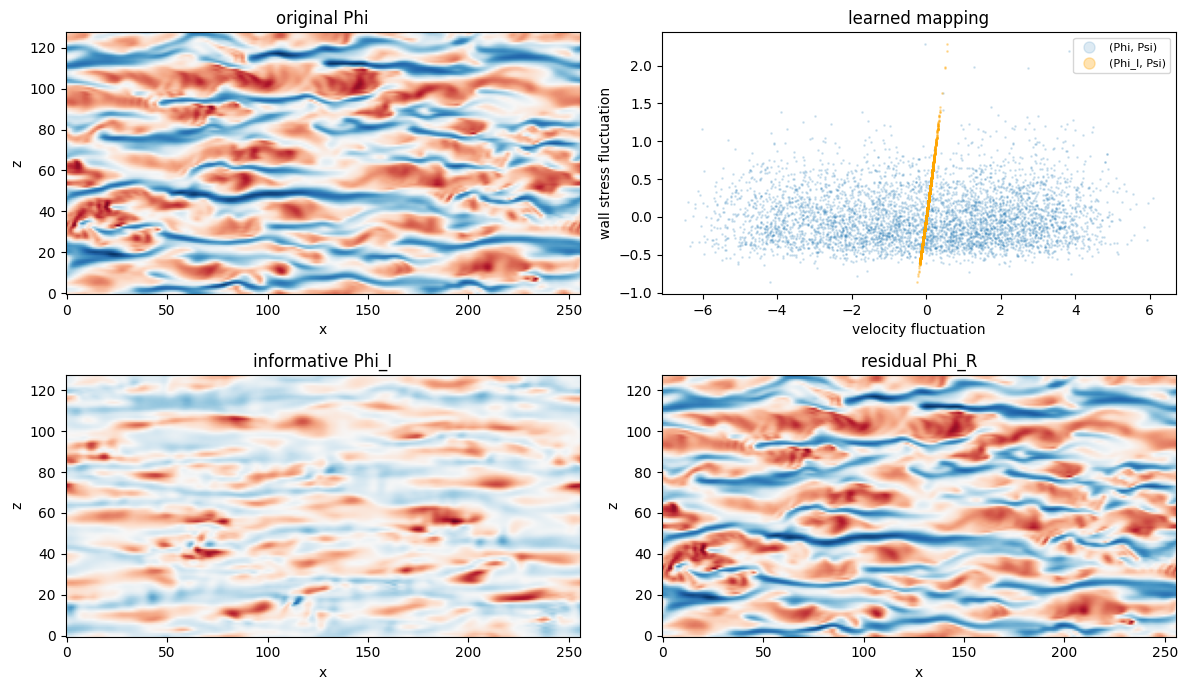

In [ ]:
snap = 0
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

for ax, fld, ttl in [(axs[0,0], Phi_s[snap], "original Phi"),
                     (axs[1,0], PhiI[snap],  "informative Phi_I"),
                     (axs[1,1], PhiR[snap],  "residual Phi_R")]:
    v = np.abs(fld).max()
    ax.imshow(fld, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto", origin="lower")
    ax.set_title(ttl); ax.set_xlabel("x"); ax.set_ylabel("z")

ax = axs[0,1]
sub = np.random.choice(Phi_s.size, 5000, replace=False)
ax.scatter(Phi_s.ravel()[sub], Psi_s.ravel()[sub], s=1, alpha=.15, label="(Phi, Psi)")
ax.scatter(PhiI.ravel()[sub],  Psi_s.ravel()[sub], s=1, alpha=.3, color="orange", label="(Phi_I, Psi)")
ax.set_xlabel("velocity fluctuation"); ax.set_ylabel("wall stress fluctuation")
ax.set_title("learned mapping")
ax.legend(markerscale=8, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
print("std(Phi_s):", Phi_s.std())
print("std(PhiI):", PhiI.std())
print("std(PhiR):", PhiR.std())

std(Phi_s): 2.5696779283587743
std(PhiI): 0.09509251
std(PhiR): 2.568691150875626


## Reading the results, and what to do next

What good looks like here:
- E_I somewhere in a middle range, not pinned at 0 or 1
- MI(PhiI, Psi) close to MI(Phi, Psi), meaning the informative part kept essentially all the information
- MI(PhiR, Psi) and MI(PhiI, PhiR) both much smaller, meaning the residual really is uninformative and the pieces really are independent
- the (Phi_I, Psi) scatter collapsing onto a much tighter curve than the raw (Phi, Psi) cloud

Things to try from here:
- rerun with a different random seed and check the numbers are stable, the optimization has local minima and one run is never proof
- try different source planes (change y_idx_source) and see how E_I changes with wall distance, the paper's figure on this shows the informative energy peaking around y+ of 10
- pull more snapshots to allow larger dtlag values and see how the decomposition degrades as the lag grows, the paper shows information decays with lag
- if the scatter plot ever looks folded rather than monotone, switch bijectiveNN to surjectiveNN with N_b=2, the training cells stay the same otherwise